[← Back to Overview](./00_overview.ipynb) | [Next: Gene Expression →](./04_gene_expression_analysis.ipynb)

# TCGA-BRCA Comprehensive Clinical Analysis

This notebook combines clinical, survival, and PAM50 molecular subtype analyses for TCGA Breast Cancer patients.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from oncolearn.api.xenabrowser import XenaCohortBuilder

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Load Clinical Data

Using the `XenaCohort` class, we can load all clinical datasets with one simple method call.
This automatically merges data from multiple sources:
- Clinical and demographic data
- Survival data
- PAM50 subtype classification

In [3]:
# Build the cohort
builder = XenaCohortBuilder()
cohort = builder.build_cohort("BRCA")

# Load clinical data
clinical = cohort.clinical()

Deduplicated brca/pam50: 141 -> 74 rows


## Column Overview

In [4]:
clinical_categories = {
    'demographic': [col for col in clinical.columns if 'demographic' in col],
    'diagnoses': [col for col in clinical.columns if 'diagnoses' in col],
    'treatments': [col for col in clinical.columns if 'treatments' in col],
    'samples': [col for col in clinical.columns if 'samples' in col],
    'project': [col for col in clinical.columns if 'project' in col],
    'annotations': [col for col in clinical.columns if 'annotations' in col],
}

In [5]:
# Display dataset information
print("Clinical Data Overview")
print(f"{'='*60}")
print(f"Total rows: {clinical.shape[0]:,}")
print(f"Total columns: {clinical.shape[1]:,}")
print(
    f"\nMemory usage: {clinical.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Count columns by category
categories = {k: len(v) for k, v in clinical_categories.items()}

# Calculate "other" category
categories['other'] = clinical.shape[1] - sum(categories.values())

print("\nColumns by category:")
for category, count in categories.items():
    if count > 0:
        pct = (count / clinical.shape[1]) * 100
        print(f"  {category.capitalize():15s}: {count:4d} ({pct:5.1f}%)")

Clinical Data Overview
Total rows: 1,257
Total columns: 89

Memory usage: 5.50 MB

Columns by category:
  Demographic    :    9 ( 10.1%)
  Diagnoses      :   30 ( 33.7%)
  Treatments     :    7 (  7.9%)
  Samples        :   15 ( 16.9%)
  Project        :    6 (  6.7%)
  Annotations    :   15 ( 16.9%)
  Other          :    7 (  7.9%)


---

# Part 1: Clinical Data Analysis

Detailed analysis of clinical and demographic data for TCGA Breast Cancer patients.

In [38]:
# Show all clinical columns by category
for category, cols in clinical_categories.items():
    print(f"\n{category.upper()} ({len(cols)} columns):")
    for col in cols:
        print(f"  - {col}")


DEMOGRAPHIC (9 columns):
  - race.demographic
  - gender.demographic
  - ethnicity.demographic
  - vital_status.demographic
  - age_at_index.demographic
  - days_to_birth.demographic
  - year_of_birth.demographic
  - year_of_death.demographic
  - days_to_death.demographic

DIAGNOSES (30 columns):
  - synchronous_malignancy.diagnoses
  - ajcc_pathologic_stage.diagnoses
  - days_to_diagnosis.diagnoses
  - last_known_disease_status.diagnoses
  - tissue_or_organ_of_origin.diagnoses
  - days_to_last_follow_up.diagnoses
  - age_at_diagnosis.diagnoses
  - primary_diagnosis.diagnoses
  - prior_malignancy.diagnoses
  - year_of_diagnosis.diagnoses
  - prior_treatment.diagnoses
  - ajcc_staging_system_edition.diagnoses
  - ajcc_pathologic_t.diagnoses
  - morphology.diagnoses
  - ajcc_pathologic_n.diagnoses
  - ajcc_pathologic_m.diagnoses
  - classification_of_tumor.diagnoses
  - icd_10_code.diagnoses
  - site_of_resection_or_biopsy.diagnoses
  - tumor_grade.diagnoses
  - progression_or_recurrenc

## Data Quality Assessment

In [7]:
# Missing data analysis
missing_data = pd.DataFrame({
    'column': clinical.columns,
    'missing_count': clinical.isnull().sum(),
    'missing_pct': (clinical.isnull().sum() / len(clinical)) * 100
})

# Sort by missing percentage
missing_data = missing_data.sort_values('missing_pct', ascending=False)

# Display columns with >50% missing data
high_missing = missing_data[missing_data['missing_pct'] > 50]
print(
    f"Columns with >50% missing data: {len(high_missing)} / {len(clinical.columns)}")
if len(high_missing) > 0:
    print("\nTop 20 columns with most missing data:")
    print(high_missing.head(20).to_string(index=False))

Columns with >50% missing data: 19 / 89

Top 20 columns with most missing data:
                            column  missing_count  missing_pct
               annotations.samples           1256    99.920446
days_to_sample_procurement.samples           1253    99.681782
        classification.annotations           1224    97.374702
          submitter_id.annotations           1224    97.374702
             entity_id.annotations           1224    97.374702
   entity_submitter_id.annotations           1224    97.374702
                 notes.annotations           1224    97.374702
      created_datetime.annotations           1224    97.374702
                 state.annotations           1224    97.374702
         annotation_id.annotations           1224    97.374702
           entity_type.annotations           1224    97.374702
     case_submitter_id.annotations           1224    97.374702
                status.annotations           1224    97.374702
               case_id.annotations    

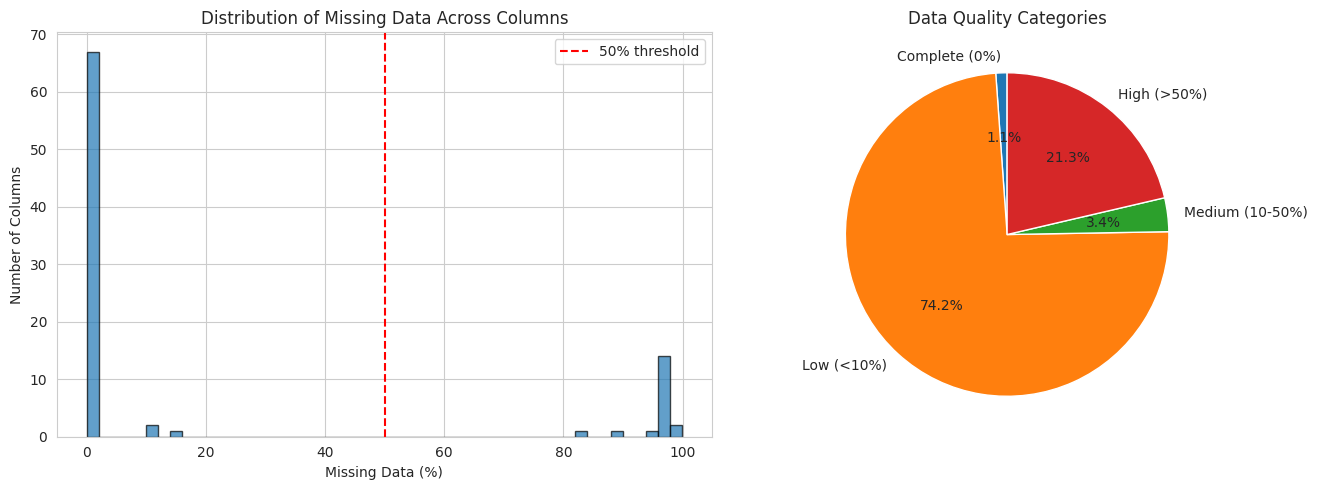

In [8]:
# Visualize missing data distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of missing percentages
axes[0].hist(missing_data['missing_pct'], bins=50,
             edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Missing Data (%)')
axes[0].set_ylabel('Number of Columns')
axes[0].set_title('Distribution of Missing Data Across Columns')
axes[0].axvline(50, color='red', linestyle='--', label='50% threshold')
axes[0].legend()

# Pie chart of data quality categories
quality_categories = {
    'Complete (0%)': len(missing_data[missing_data['missing_pct'] == 0]),
    'Low (<10%)': len(missing_data[(missing_data['missing_pct'] > 0) & (missing_data['missing_pct'] < 10)]),
    'Medium (10-50%)': len(missing_data[(missing_data['missing_pct'] >= 10) & (missing_data['missing_pct'] < 50)]),
    'High (>50%)': len(missing_data[missing_data['missing_pct'] >= 50])
}

axes[1].pie(quality_categories.values(),
            labels=quality_categories.keys(), autopct='%1.1f%%', startangle=90)
axes[1].set_title('Data Quality Categories')

plt.tight_layout()
plt.show()

## Demographic Analysis

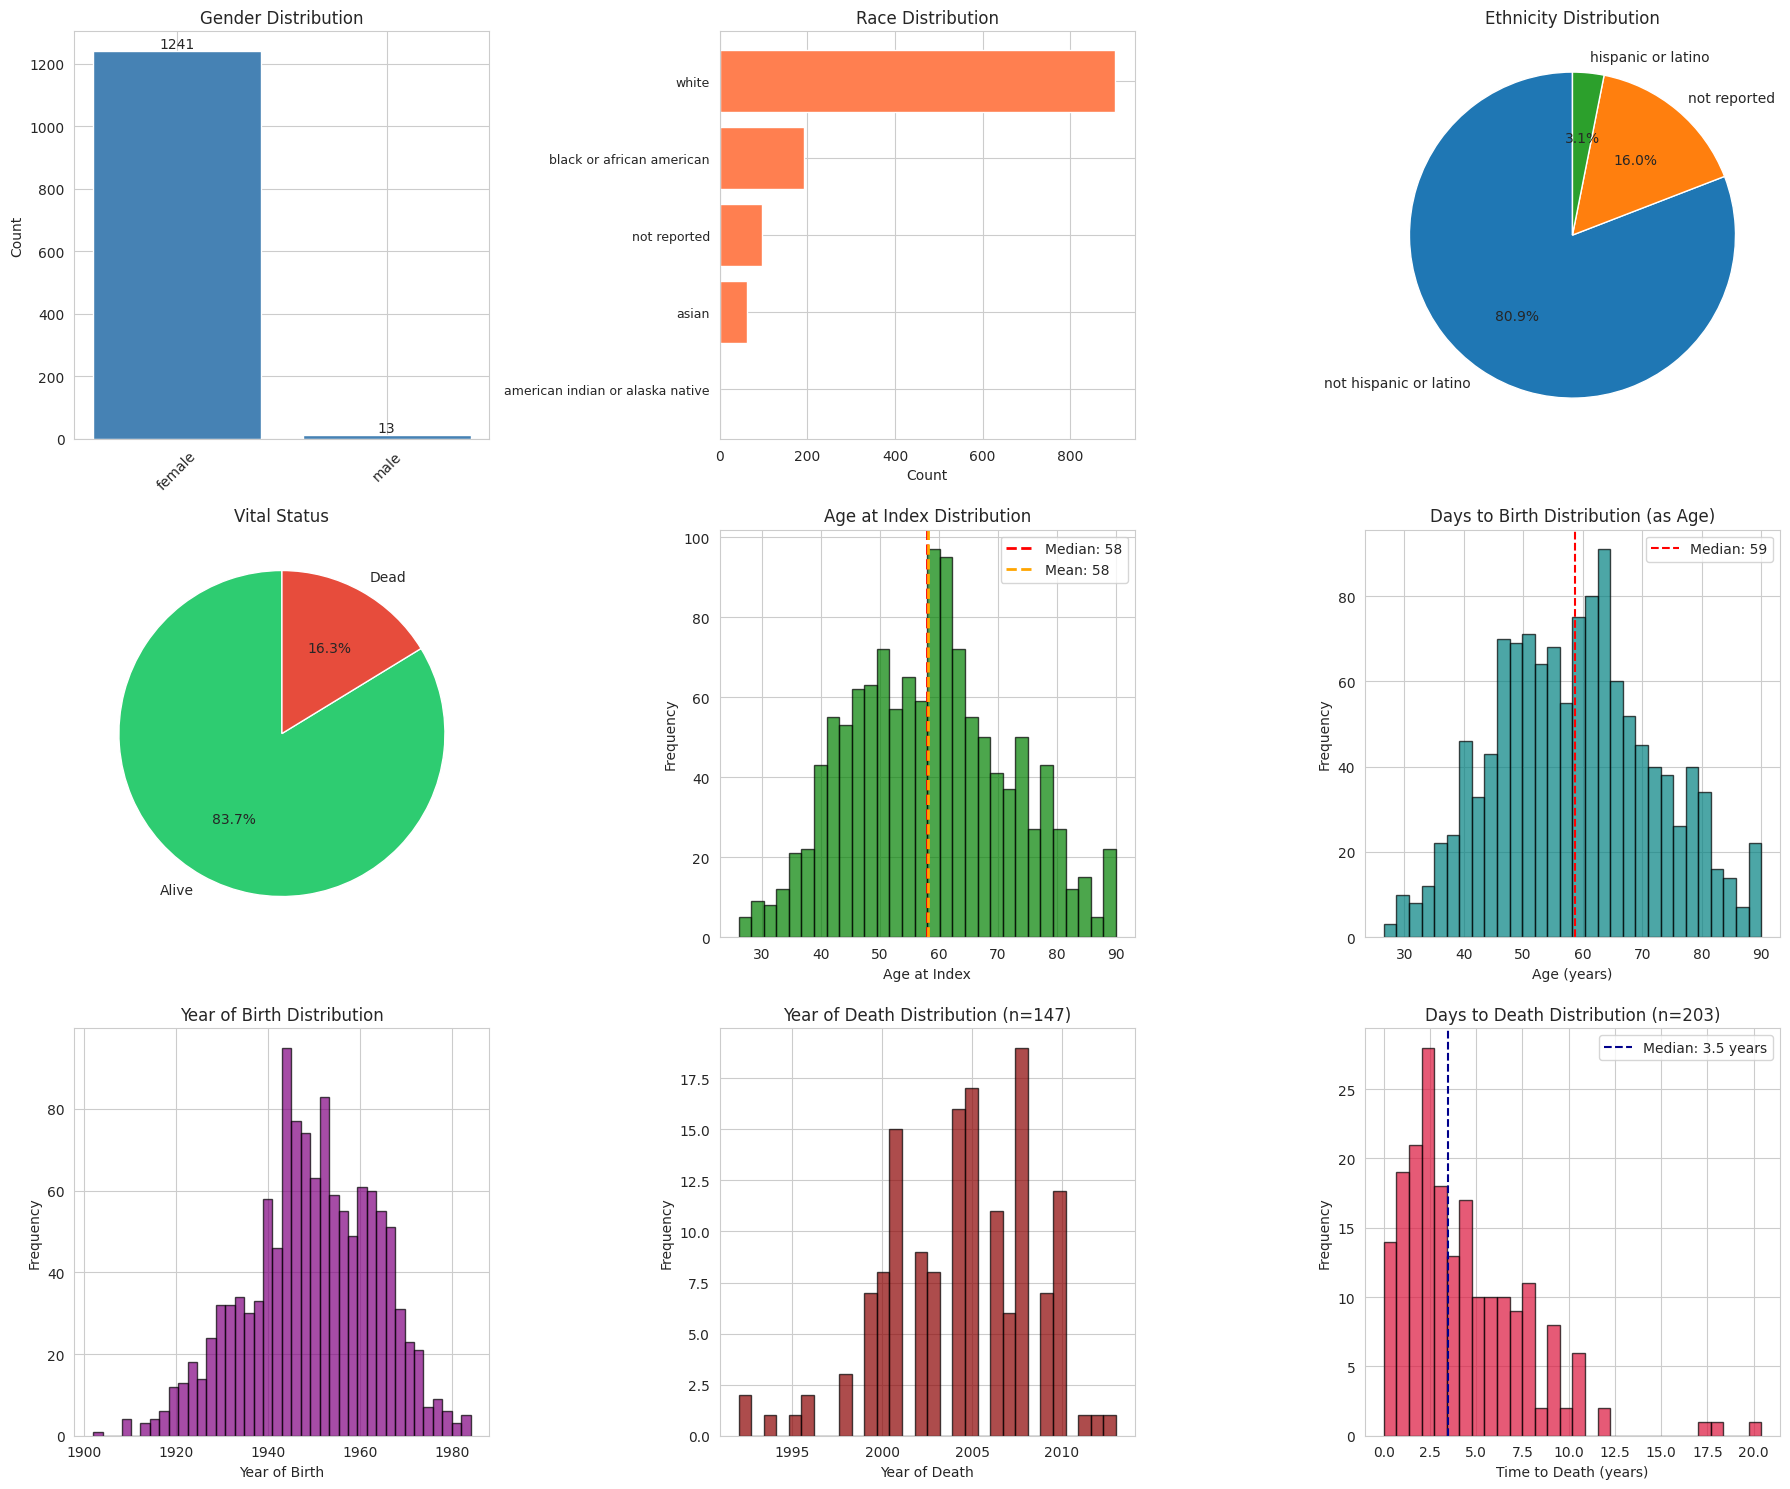

In [37]:
# Visualize all 9 demographic columns
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

# Gender
if 'gender.demographic' in clinical.columns:
    gender_counts = clinical['gender.demographic'].value_counts()
    axes[0].bar(range(len(gender_counts)),
                gender_counts.values, color='steelblue')
    axes[0].set_xticks(range(len(gender_counts)))
    axes[0].set_xticklabels(gender_counts.index, rotation=45)
    axes[0].set_title('Gender Distribution')
    axes[0].set_ylabel('Count')
    for i, v in enumerate(gender_counts.values):
        axes[0].text(i, v + 10, str(v), ha='center')

# Race
if 'race.demographic' in clinical.columns:
    race_counts = clinical['race.demographic'].value_counts().head(8)
    axes[1].barh(range(len(race_counts)), race_counts.values, color='coral')
    axes[1].set_yticks(range(len(race_counts)))
    axes[1].set_yticklabels(race_counts.index, fontsize=9)
    axes[1].set_xlabel('Count')
    axes[1].set_title('Race Distribution')
    axes[1].invert_yaxis()

# Ethnicity
if 'ethnicity.demographic' in clinical.columns:
    eth_counts = clinical['ethnicity.demographic'].value_counts()
    axes[2].pie(eth_counts.values, labels=eth_counts.index,
                autopct='%1.1f%%', startangle=90)
    axes[2].set_title('Ethnicity Distribution')

# Vital status
if 'vital_status.demographic' in clinical.columns:
    vital_counts = clinical['vital_status.demographic'].value_counts()
    colors = ['#2ecc71', '#e74c3c'] if len(vital_counts) == 2 else None
    axes[3].pie(vital_counts.values, labels=vital_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[3].set_title('Vital Status')

# Age at index
if 'age_at_index.demographic' in clinical.columns:
    age_data = pd.to_numeric(
        clinical['age_at_index.demographic'], errors='coerce').dropna()
    axes[4].hist(age_data, bins=30, color='green',
                 alpha=0.7, edgecolor='black')
    axes[4].axvline(age_data.median(), color='red', linestyle='--', linewidth=2,
                    label=f'Median: {age_data.median():.0f}')
    axes[4].axvline(age_data.mean(), color='orange', linestyle='--', linewidth=2,
                    label=f'Mean: {age_data.mean():.0f}')
    axes[4].set_xlabel('Age at Index')
    axes[4].set_ylabel('Frequency')
    axes[4].set_title('Age at Index Distribution')
    axes[4].legend()

# Days to birth
if 'days_to_birth.demographic' in clinical.columns:
    dtb_data = pd.to_numeric(
        clinical['days_to_birth.demographic'], errors='coerce').dropna()
    # Convert to years (negative values, so multiply by -1)
    dtb_years = (dtb_data * -1) / 365.25
    axes[5].hist(dtb_years, bins=30, color='teal',
                 alpha=0.7, edgecolor='black')
    axes[5].set_xlabel('Age (years)')
    axes[5].set_ylabel('Frequency')
    axes[5].set_title('Days to Birth Distribution (as Age)')
    axes[5].axvline(dtb_years.median(), color='red', linestyle='--',
                    label=f'Median: {dtb_years.median():.0f}')
    axes[5].legend()

# Year of birth
if 'year_of_birth.demographic' in clinical.columns:
    yob_data = pd.to_numeric(
        clinical['year_of_birth.demographic'], errors='coerce').dropna()
    axes[6].hist(yob_data, bins=40, color='purple',
                 alpha=0.7, edgecolor='black')
    axes[6].set_xlabel('Year of Birth')
    axes[6].set_ylabel('Frequency')
    axes[6].set_title('Year of Birth Distribution')

# Year of death
if 'year_of_death.demographic' in clinical.columns:
    yod_data = pd.to_numeric(
        clinical['year_of_death.demographic'], errors='coerce').dropna()
    if len(yod_data) > 0:
        axes[7].hist(yod_data, bins=30, color='darkred',
                     alpha=0.7, edgecolor='black')
        axes[7].set_xlabel('Year of Death')
        axes[7].set_ylabel('Frequency')
        axes[7].set_title(f'Year of Death Distribution (n={len(yod_data)})')
    else:
        axes[7].text(0.5, 0.5, 'No Data Available', ha='center',
                     va='center', transform=axes[7].transAxes, fontsize=12)
        axes[7].set_title('Year of Death Distribution')

# Days to death
if 'days_to_death.demographic' in clinical.columns:
    dtd_data = pd.to_numeric(
        clinical['days_to_death.demographic'], errors='coerce').dropna()
    if len(dtd_data) > 0:
        dtd_years = dtd_data / 365.25
        axes[8].hist(dtd_years, bins=30, color='crimson',
                     alpha=0.7, edgecolor='black')
        axes[8].set_xlabel('Time to Death (years)')
        axes[8].set_ylabel('Frequency')
        axes[8].set_title(f'Days to Death Distribution (n={len(dtd_data)})')
        axes[8].axvline(dtd_years.median(), color='darkblue', linestyle='--',
                        label=f'Median: {dtd_years.median():.1f} years')
        axes[8].legend()
    else:
        axes[8].text(0.5, 0.5, 'No Data Available', ha='center',
                     va='center', transform=axes[8].transAxes, fontsize=12)
        axes[8].set_title('Days to Death Distribution')

plt.tight_layout()
plt.show()

## Clinical Stage Analysis

In [10]:
# Find stage-related columns
stage_cols = [c for c in clinical.columns if 'stage' in c.lower()]
print(f"Stage-related columns found: {len(stage_cols)}")
for col in stage_cols[:10]:
    print(f"  - {col}")

Stage-related columns found: 1
  - ajcc_pathologic_stage.diagnoses



Using column: ajcc_pathologic_stage.diagnoses

Pathologic Stage Distribution:
ajcc_pathologic_stage.diagnoses
Stage IIA     409
Stage IIB     303
Stage IIIA    174
Stage I       111
Stage IA       93
Stage IIIC     71
Stage IIIB     31
Stage IV       22
Stage X        13
Stage IB        7
Stage II        6
Stage III       2
Name: count, dtype: int64


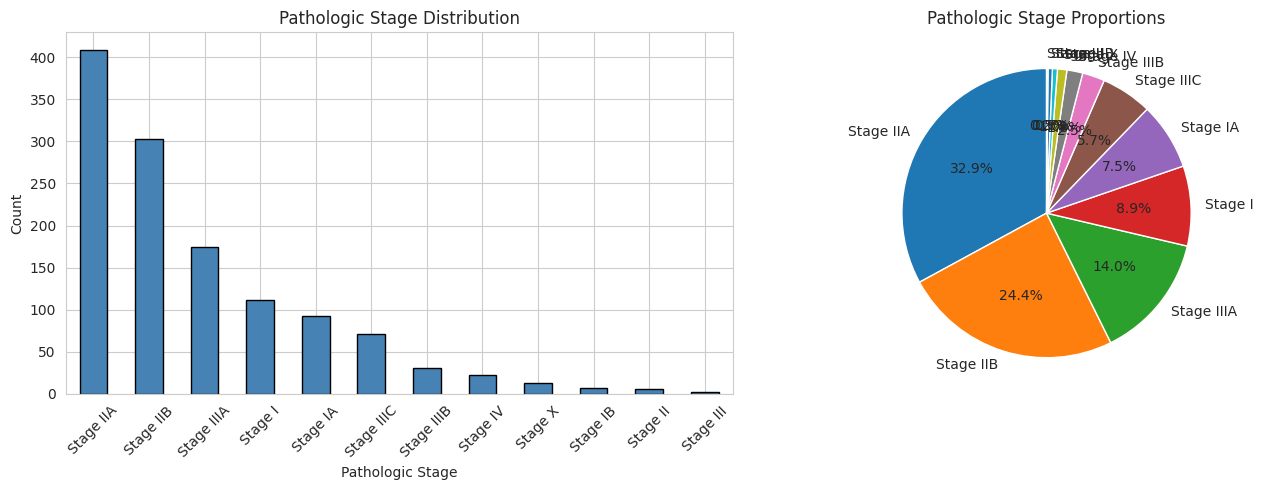

In [11]:
# Analyze pathologic stage
pathologic_stage_cols = [
    c for c in stage_cols if 'pathologic' in c.lower() or 'ajcc' in c.lower()]
if pathologic_stage_cols:
    stage_col = pathologic_stage_cols[0]
    print(f"\nUsing column: {stage_col}")

    stage_counts = clinical[stage_col].value_counts()
    print(f"\nPathologic Stage Distribution:")
    print(stage_counts)

    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    stage_counts.plot(
        kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Pathologic Stage')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Pathologic Stage Distribution')
    axes[0].tick_params(axis='x', rotation=45)

    # Pie chart
    axes[1].pie(stage_counts.values, labels=stage_counts.index,
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Pathologic Stage Proportions')

    plt.tight_layout()
    plt.show()

## Tumor Characteristics

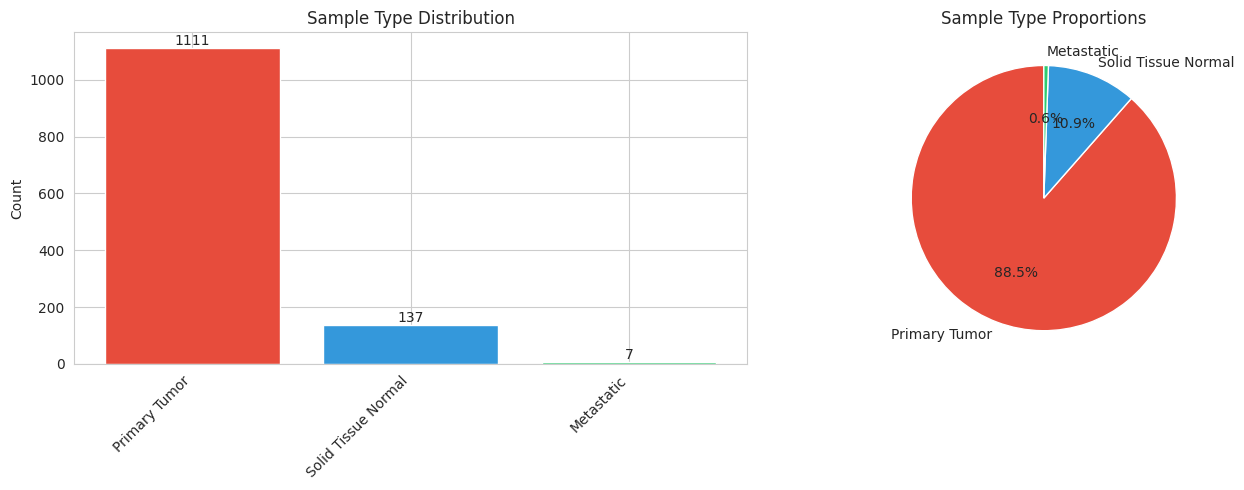


Sample Type Distribution:
sample_type.samples
Primary Tumor          1111
Solid Tissue Normal     137
Metastatic                7
Name: count, dtype: int64


In [12]:
# Sample type distribution
if 'sample_type.samples' in clinical.columns:
    sample_types = clinical['sample_type.samples'].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar chart
    axes[0].bar(range(len(sample_types)), sample_types.values,
                color=['#e74c3c', '#3498db', '#2ecc71', '#f39c12'][:len(sample_types)])
    axes[0].set_xticks(range(len(sample_types)))
    axes[0].set_xticklabels(sample_types.index, rotation=45, ha='right')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Sample Type Distribution')
    for i, v in enumerate(sample_types.values):
        axes[0].text(i, v + 10, str(v), ha='center')

    # Pie chart
    axes[1].pie(sample_types.values, labels=sample_types.index, autopct='%1.1f%%',
                colors=['#e74c3c', '#3498db', '#2ecc71',
                        '#f39c12'][:len(sample_types)],
                startangle=90)
    axes[1].set_title('Sample Type Proportions')

    plt.tight_layout()
    plt.show()

    print("\nSample Type Distribution:")
    print(sample_types)

## Histology Analysis

In [13]:
# Histology-related columns
histology_cols = [c for c in clinical.columns if 'histolog' in c.lower(
) or 'morpholog' in c.lower()]
print(f"Histology columns: {len(histology_cols)}")
for col in histology_cols[:10]:
    print(f"  - {col}")

# Analyze primary diagnosis
primary_diag_cols = [
    c for c in clinical.columns if 'primary_diagnosis' in c.lower()]
if primary_diag_cols:
    diag_col = primary_diag_cols[0]
    print(f"\nPrimary Diagnosis Distribution (using {diag_col}):")
    diag_counts = clinical[diag_col].value_counts()
    print(diag_counts.head(10))

Histology columns: 1
  - morphology.diagnoses

Primary Diagnosis Distribution (using primary_diagnosis.diagnoses):
primary_diagnosis.diagnoses
Infiltrating duct carcinoma, NOS                            899
Lobular carcinoma, NOS                                      218
Infiltrating duct and lobular carcinoma                      38
Infiltrating duct mixed with other types of carcinoma        21
Metaplastic carcinoma, NOS                                   17
Mucinous adenocarcinoma                                      16
Infiltrating lobular mixed with other types of carcinoma      8
Medullary carcinoma, NOS                                      8
Intraductal papillary adenocarcinoma with invasion            6
Intraductal micropapillary carcinoma                          4
Name: count, dtype: int64


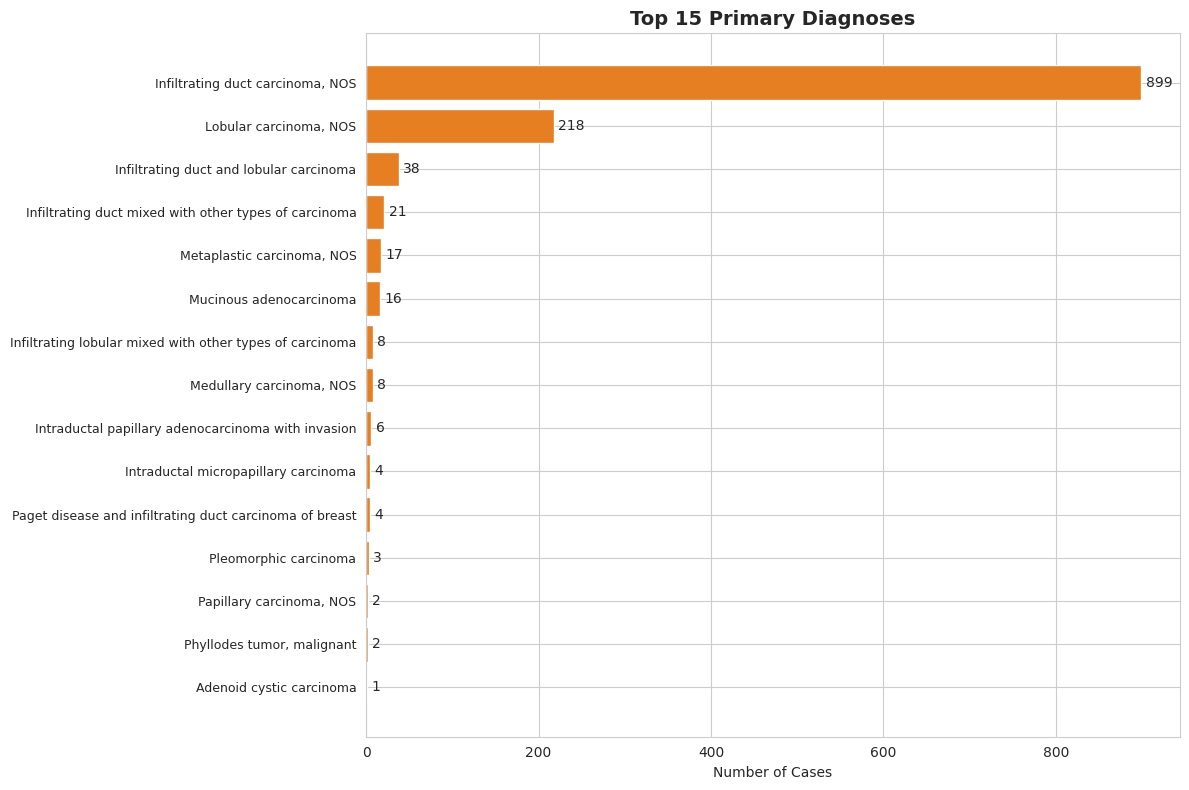


Total unique primary diagnoses: 22


In [14]:
# Primary diagnosis distribution
if 'primary_diagnosis.diagnoses' in clinical.columns:
    primary_diag = clinical['primary_diagnosis.diagnoses'].value_counts().head(
        15)

    plt.figure(figsize=(12, 8))
    plt.barh(range(len(primary_diag)), primary_diag.values, color='#e67e22')
    plt.yticks(range(len(primary_diag)), primary_diag.index, fontsize=9)
    plt.xlabel('Number of Cases')
    plt.title('Top 15 Primary Diagnoses', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()

    # Add value labels
    for i, v in enumerate(primary_diag.values):
        plt.text(v + 5, i, str(v), va='center')

    plt.tight_layout()
    plt.show()

    print(
        f"\nTotal unique primary diagnoses: {clinical['primary_diagnosis.diagnoses'].nunique()}")

## Treatment Analysis

In [15]:
# Treatment-related columns
treatment_cols = [
    c for c in clinical.columns if 'treatment' in c.lower() or 'therapy' in c.lower()]
print(f"Treatment columns: {len(treatment_cols)}")
for col in treatment_cols[:15]:
    print(f"  - {col}")

Treatment columns: 8
  - prior_treatment.diagnoses
  - treatment_id.treatments.diagnoses
  - submitter_id.treatments.diagnoses
  - treatment_type.treatments.diagnoses
  - treatment_or_therapy.treatments.diagnoses
  - created_datetime.treatments.diagnoses
  - updated_datetime.treatments.diagnoses
  - state.treatments.diagnoses


In [16]:
# Analyze specific treatments if available
radiation_cols = [c for c in treatment_cols if 'radiation' in c.lower()]
if radiation_cols:
    rad_col = radiation_cols[0]
    print(f"\nRadiation Treatment (using {rad_col}):")
    print(clinical[rad_col].value_counts())

pharma_cols = [c for c in treatment_cols if 'pharma' in c.lower()]
if pharma_cols:
    pharma_col = pharma_cols[0]
    print(f"\nPharmaceutical Treatment (using {pharma_col}):")
    print(clinical[pharma_col].value_counts())

---

# Part 2: Survival Data Analysis

Detailed analysis of survival outcomes including overall survival (OS), progression-free interval (PFI), disease-specific survival (DSS), and disease-free interval (DFI).

In [17]:
# Extract survival-specific columns
survival_cols = [col for col in clinical.columns if any(
    x in col for x in ['OS', 'PFI', 'DSS', 'DFI', 'survival', 'time', '_PATIENT'])]
survival = clinical[['sample'] + survival_cols].copy(
) if 'sample' in clinical.columns else clinical[survival_cols].copy()

# Remove duplicates based on sample
if 'sample' in survival.columns:
    survival = survival.drop_duplicates(subset='sample')

print(f"Survival data shape: {survival.shape}")
print(f"Number of samples: {len(survival)}")
print(f"\nSurvival-related columns: {survival_cols}")

survival.head(10)

Survival data shape: (1257, 8)
Number of samples: 1257

Survival-related columns: ['created_datetime.annotations', 'updated_datetime.annotations', 'created_datetime.treatments.diagnoses', 'updated_datetime.treatments.diagnoses', 'OS.time', 'OS', '_PATIENT']


,sample,created_datetime.annotations,updated_datetime.annotations,created_datetime.treatments.diagnoses,updated_datetime.treatments.diagnoses,OS.time,OS,_PATIENT
0,TCGA-3C-AAAU-01A,NaN,NaN,"['', '2019-04-28T13:35:03.916806-05:00']","['2019-07-31T21:21:01.590763-05:00', '2019-07-...",4047.0,0.0,TCGA-3C-AAAU
1,TCGA-3C-AALI-01A,NaN,NaN,"['2019-04-28T13:33:48.244636-05:00', '']","['2019-07-31T21:19:29.987911-05:00', '2019-07-...",4005.0,0.0,TCGA-3C-AALI
2,TCGA-3C-AALJ-01A,NaN,NaN,"['', '2019-04-28T08:37:49.629032-05:00']","['2019-07-31T15:17:14.528221-05:00', '2019-07-...",1474.0,0.0,TCGA-3C-AALJ
3,TCGA-3C-AALK-01A,NaN,NaN,"['2019-04-28T13:40:08.180007-05:00', '']","['2019-07-31T21:27:10.423927-05:00', '2019-07-...",1448.0,0.0,TCGA-3C-AALK
4,TCGA-4H-AAAK-01A,NaN,NaN,"['2019-04-28T08:37:04.368384-05:00', '']","['2019-07-31T15:16:22.301720-05:00', '2019-07-...",348.0,0.0,TCGA-4H-AAAK
5,TCGA-5L-AAT0-01A,NaN,NaN,"['', '2019-04-28T13:36:44.468306-05:00']","['2019-07-31T21:23:04.043540-05:00', '2019-07-...",1477.0,0.0,TCGA-5L-AAT0
6,TCGA-5L-AAT1-01A,2014-11-25T00:00:00,2018-08-23T16:36:27.780612-05:00,"['2019-04-28T13:30:41.595131-05:00', '']","['2019-07-31T21:15:47.269591-05:00', '2019-07-...",1471.0,0.0,TCGA-5L-AAT1
7,TCGA-5T-A9QA-01A,NaN,NaN,"['', '2019-04-28T13:31:51.876663-05:00']","['2019-07-31T21:17:13.416089-05:00', '2019-07-...",303.0,0.0,TCGA-5T-A9QA
8,TCGA-A1-A0SB-01A,NaN,NaN,"['', '2019-04-28T13:29:05.968748-05:00']","['2019-07-31T21:13:52.145227-05:00', '2019-07-...",259.0,0.0,TCGA-A1-A0SB
9,TCGA-A1-A0SD-01A,NaN,NaN,"['', '2019-04-28T13:40:12.888182-05:00']","['2019-07-31T21:27:16.149819-05:00', '2019-07-...",437.0,0.0,TCGA-A1-A0SD


In [18]:
# Data types and basic info
print("\nColumn Information:")
print(survival.dtypes)
print("\nMissing Data:")
for col in survival.columns:
    missing = survival[col].isna().sum()
    missing_pct = (missing / len(survival)) * 100
    print(f"{col:40s}: {missing:5d} ({missing_pct:5.1f}%)")


Column Information:
sample                                    object
created_datetime.annotations              object
updated_datetime.annotations              object
created_datetime.treatments.diagnoses     object
updated_datetime.treatments.diagnoses     object
OS.time                                  float64
OS                                       float64
_PATIENT                                  object
dtype: object

Missing Data:
sample                                  :     0 (  0.0%)
created_datetime.annotations            :  1224 ( 97.4%)
updated_datetime.annotations            :  1224 ( 97.4%)
created_datetime.treatments.diagnoses   :     3 (  0.2%)
updated_datetime.treatments.diagnoses   :     3 (  0.2%)
OS.time                                 :    25 (  2.0%)
OS                                      :    25 (  2.0%)
_PATIENT                                :    25 (  2.0%)


## Overall Survival (OS) Analysis

In [19]:
# OS columns
os_cols = [col for col in survival.columns if 'OS' in col]
print(f"Overall Survival columns: {os_cols}")

if len(os_cols) >= 2:
    # Typically OS (event) and OS.time
    os_event_col = [c for c in os_cols if c == 'OS' or 'event' in c.lower()][0] if any(
        'OS' in c or 'event' in c.lower() for c in os_cols) else os_cols[0]
    os_time_col = [c for c in os_cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in os_cols) else os_cols[1]

    print(f"\nEvent column: {os_event_col}")
    print(f"Time column: {os_time_col}")

    # Event distribution
    print(f"\nOS Event Distribution:")
    print(survival[os_event_col].value_counts())

    # Time statistics
    os_time = pd.to_numeric(survival[os_time_col], errors='coerce')
    print(f"\nOS Time Statistics (days):")
    print(os_time.describe())
    print(
        f"\nIn years: Min={os_time.min()/365.25:.1f}, Max={os_time.max()/365.25:.1f}, Median={os_time.median()/365.25:.1f}")

Overall Survival columns: ['OS.time', 'OS']

Event column: OS
Time column: OS.time

OS Event Distribution:
OS
0.0    1031
1.0     201
Name: count, dtype: int64

OS Time Statistics (days):
count    1232.00000
mean     1273.17776
std      1154.55418
min         1.00000
25%       486.50000
50%       922.00000
75%      1734.50000
max      8605.00000
Name: OS.time, dtype: float64

In years: Min=0.0, Max=23.6, Median=2.5


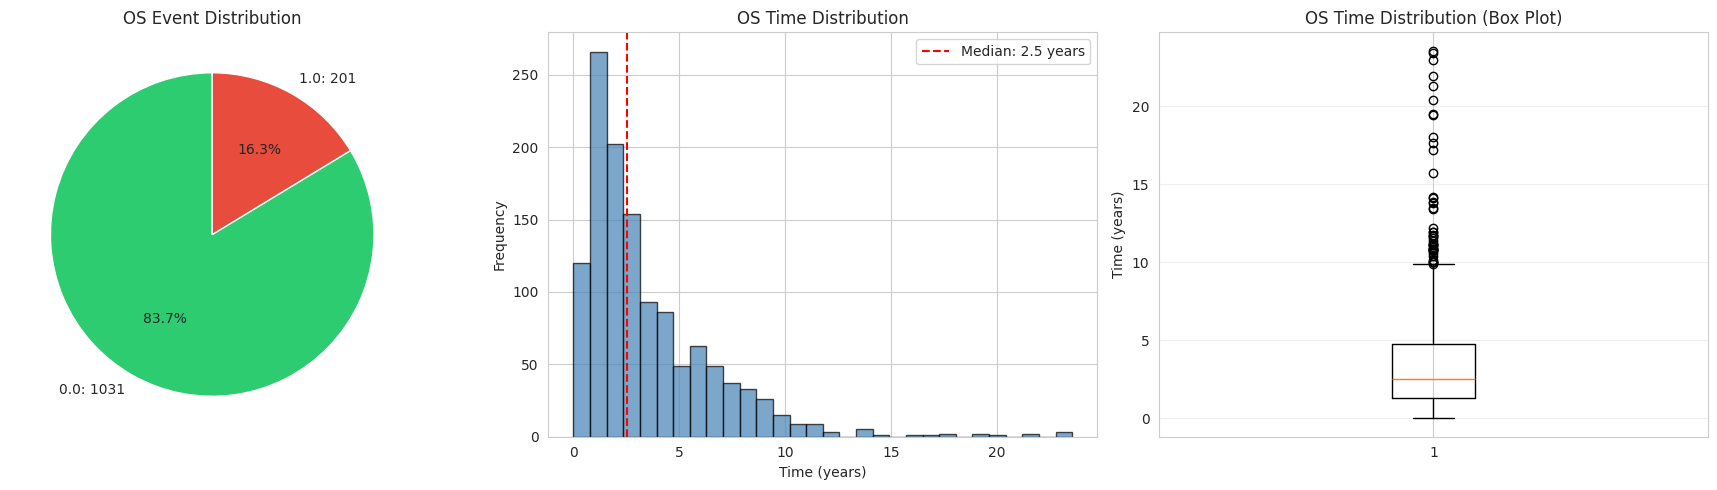


OS Event by Time Quartiles:
OS        0.0  1.0   All
OS.time                 
Q1        277   31   308
Q2        267   41   308
Q3        252   56   308
Q4        235   73   308
All      1031  201  1232


In [20]:
# Visualize OS
if len(os_cols) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Event distribution
    event_counts = survival[os_event_col].value_counts()
    colors = ['#2ecc71', '#e74c3c'] if len(event_counts) == 2 else None
    axes[0].pie(event_counts.values, labels=[f'{idx}: {val}' for idx, val in zip(event_counts.index, event_counts.values)],
                autopct='%1.1f%%', colors=colors, startangle=90)
    axes[0].set_title('OS Event Distribution')

    # Time distribution (histogram)
    os_time_clean = os_time.dropna()
    axes[1].hist(os_time_clean / 365.25, bins=30,
                 edgecolor='black', alpha=0.7, color='steelblue')
    axes[1].set_xlabel('Time (years)')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('OS Time Distribution')
    axes[1].axvline(os_time_clean.median() / 365.25, color='red', linestyle='--',
                    label=f'Median: {os_time_clean.median()/365.25:.1f} years')
    axes[1].legend()

    # Box plot
    axes[2].boxplot(os_time_clean / 365.25, vert=True)
    axes[2].set_ylabel('Time (years)')
    axes[2].set_title('OS Time Distribution (Box Plot)')
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Cross-tabulation of event by time quartiles
    os_time_quartiles = pd.qcut(
        os_time, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
    os_event_clean = pd.to_numeric(survival[os_event_col], errors='coerce')
    print(f"\nOS Event by Time Quartiles:")
    print(pd.crosstab(os_time_quartiles, os_event_clean, margins=True))

## Progression-Free Interval (PFI) Analysis

In [21]:
# PFI columns
pfi_cols = [col for col in survival.columns if 'PFI' in col]
print(f"PFI columns: {pfi_cols}")

if pfi_cols:
    # Analyze PFI data
    for col in pfi_cols:
        print(f"\n{col}:")
        if survival[col].dtype in ['int64', 'float64']:
            print(survival[col].describe())
        else:
            print(survival[col].value_counts())

PFI columns: []


## Disease-Specific Survival (DSS) Analysis

In [22]:
# DSS columns
dss_cols = [col for col in survival.columns if 'DSS' in col]
print(f"DSS columns: {dss_cols}")

if dss_cols:
    # Analyze DSS data
    for col in dss_cols:
        print(f"\n{col}:")
        if survival[col].dtype in ['int64', 'float64']:
            print(survival[col].describe())
        else:
            print(survival[col].value_counts())

DSS columns: []


## Disease-Free Interval (DFI) Analysis

In [23]:
# DFI columns
dfi_cols = [col for col in survival.columns if 'DFI' in col]
print(f"DFI columns: {dfi_cols}")

if dfi_cols:
    # Analyze DFI data
    for col in dfi_cols:
        print(f"\n{col}:")
        if survival[col].dtype in ['int64', 'float64']:
            print(survival[col].describe())
        else:
            print(survival[col].value_counts())

DFI columns: []


## Survival Endpoints Comparison

In [24]:
# Compare all survival endpoints
survival_types = ['OS', 'PFI', 'DSS', 'DFI']
survival_labels = ['Overall Survival', 'Progression-Free Interval',
                   'Disease-Specific Survival', 'Disease-Free Interval']

# Create summary
summary_data = []
for stype, label in zip(survival_types, survival_labels):
    cols = [c for c in survival.columns if stype in c]
    if cols:
        event_col = [c for c in cols if 'time' not in c.lower()][0] if any(
            'time' not in c.lower() for c in cols) else None
        time_col = [c for c in cols if 'time' in c.lower()][0] if any(
            'time' in c.lower() for c in cols) else None

        if event_col:
            events = pd.to_numeric(survival[event_col], errors='coerce')
            event_rate = events.sum() / len(events.dropna()) * \
                100 if len(events.dropna()) > 0 else 0
        else:
            event_rate = None

        if time_col:
            stime = pd.to_numeric(survival[time_col], errors='coerce')
            median_time = stime.median() / 365.25 if not stime.isna().all() else None
        else:
            median_time = None

        summary_data.append({
            'Endpoint': label,
            'Type': stype,
            'Event Column': event_col,
            'Time Column': time_col,
            'Event Rate (%)': f'{event_rate:.1f}' if event_rate is not None else 'N/A',
            'Median Time (years)': f'{median_time:.1f}' if median_time is not None else 'N/A'
        })

summary_df = pd.DataFrame(summary_data)
print("\nSurvival Endpoints Summary:")
print(summary_df.to_string(index=False))


Survival Endpoints Summary:
        Endpoint Type Event Column Time Column Event Rate (%) Median Time (years)
Overall Survival   OS           OS     OS.time           16.3                 2.5


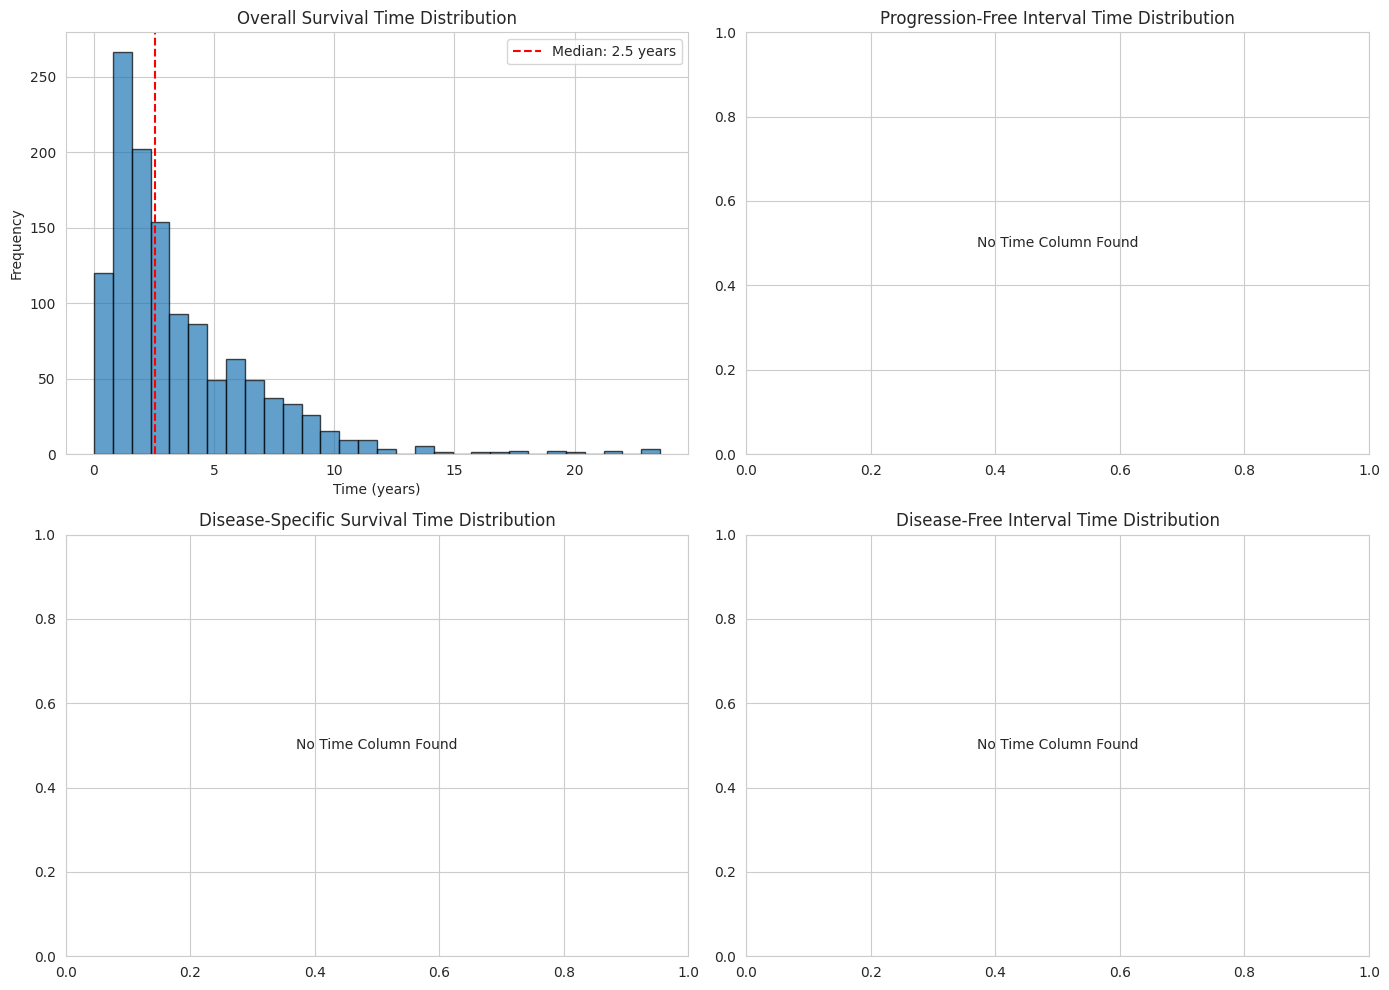

In [25]:
# Visualize survival times comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (stype, label) in enumerate(zip(survival_types, survival_labels)):
    cols = [c for c in survival.columns if stype in c]
    time_col = [c for c in cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in cols) else None

    if time_col:
        stime = pd.to_numeric(survival[time_col], errors='coerce').dropna()
        if len(stime) > 0:
            axes[i].hist(stime / 365.25, bins=30,
                         edgecolor='black', alpha=0.7, color=f'C{i}')
            axes[i].set_xlabel('Time (years)')
            axes[i].set_ylabel('Frequency')
            axes[i].set_title(f'{label} Time Distribution')
            axes[i].axvline(stime.median() / 365.25, color='red', linestyle='--',
                            label=f'Median: {stime.median()/365.25:.1f} years')
            axes[i].legend()
        else:
            axes[i].text(0.5, 0.5, 'No Data Available', ha='center',
                         va='center', transform=axes[i].transAxes)
            axes[i].set_title(f'{label} Time Distribution')
    else:
        axes[i].text(0.5, 0.5, 'No Time Column Found', ha='center',
                     va='center', transform=axes[i].transAxes)
        axes[i].set_title(f'{label} Time Distribution')

plt.tight_layout()
plt.show()

## Survival Event Summary

In [26]:
# Create comprehensive event summary
event_summary = []
for stype in survival_types:
    cols = [c for c in survival.columns if stype in c]
    event_col = [c for c in cols if 'time' not in c.lower()][0] if any(
        'time' not in c.lower() for c in cols) else None

    if event_col:
        events = pd.to_numeric(survival[event_col], errors='coerce')
        censored = (events == 0).sum()
        deceased = (events == 1).sum()
        missing = events.isna().sum()
        total = len(events)

        event_summary.append({
            'Type': stype,
            'Censored (0)': censored,
            'Event (1)': deceased,
            'Missing': missing,
            'Total': total,
            'Event Rate (%)': f'{(deceased / (total - missing) * 100):.1f}' if (total - missing) > 0 else 'N/A'
        })

if event_summary:
    event_df = pd.DataFrame(event_summary)
    print("\nSurvival Event Summary:")
    print(event_df.to_string(index=False))


Survival Event Summary:
Type  Censored (0)  Event (1)  Missing  Total Event Rate (%)
  OS          1031        201       25   1257           16.3


---

# Part 3: PAM50 Molecular Subtype Analysis

Detailed analysis of PAM50 molecular subtypes for breast cancer classification.

In [27]:
# Extract PAM50-related columns
pam50_cols = ['sample'] + \
    [col for col in clinical.columns if 'PAM50' in col or 'pam50' in col.lower()]
pam50 = clinical[pam50_cols].copy() if pam50_cols else clinical.copy()

# Remove duplicates based on sample
if 'sample' in pam50.columns:
    pam50 = pam50.drop_duplicates(subset='sample')

print(f"PAM50 data shape: {pam50.shape}")
print(f"Number of samples: {len(pam50)}")
print(
    f"\nPAM50-related columns: {[col for col in pam50.columns if col != 'sample']}")

pam50.head(10)

PAM50 data shape: (1257, 2)
Number of samples: 1257

PAM50-related columns: ['PAM50']


,sample,PAM50
0,TCGA-3C-AAAU-01A,NaN
1,TCGA-3C-AALI-01A,NaN
2,TCGA-3C-AALJ-01A,Unknown
3,TCGA-3C-AALK-01A,NaN
4,TCGA-4H-AAAK-01A,Unknown
5,TCGA-5L-AAT0-01A,NaN
6,TCGA-5L-AAT1-01A,NaN
7,TCGA-5T-A9QA-01A,NaN
8,TCGA-A1-A0SB-01A,NaN
9,TCGA-A1-A0SD-01A,NaN


In [28]:
# Data info
print("\nData Types:")
print(pam50.dtypes)

print("\nMissing Data:")
for col in pam50.columns:
    missing = pam50[col].isna().sum()
    missing_pct = (missing / len(pam50)) * 100
    print(f"{col:30s}: {missing:5d} ({missing_pct:5.1f}%)")


Data Types:
sample    object
PAM50     object
dtype: object

Missing Data:
sample                        :     0 (  0.0%)
PAM50                         :  1183 ( 94.1%)


## Subtype Distribution

In [29]:
# Find subtype column
subtype_cols = [
    col for col in pam50.columns if 'subtype' in col.lower() or col == 'Call']
print(f"Potential subtype columns: {subtype_cols}")

if subtype_cols:
    subtype_col = subtype_cols[0]
    print(f"\nUsing column: {subtype_col}")

    # Subtype distribution
    subtype_counts = pam50[subtype_col].value_counts()
    print(f"\nPAM50 Subtype Distribution:")
    print(subtype_counts)
    print(f"\nTotal samples: {subtype_counts.sum()}")

    # Percentages
    print(f"\nPercentage Distribution:")
    for subtype, count in subtype_counts.items():
        pct = (count / subtype_counts.sum()) * 100
        print(f"{subtype:15s}: {count:4d} ({pct:5.1f}%)")

Potential subtype columns: []


In [30]:
# Visualize subtype distribution
if subtype_cols:
    # Define colors for each subtype
    color_map = {
        'Basal': '#E41A1C',
        'Her2': '#377EB8',
        'LumA': '#4DAF4A',
        'LumB': '#984EA3',
        'Normal': '#FF7F00'
    }

    # Map colors to actual subtypes in data
    actual_subtypes = pam50[subtype_col].unique()
    colors = [color_map.get(st, '#999999') for st in subtype_counts.index]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Bar plot
    axes[0].bar(range(len(subtype_counts)), subtype_counts.values,
                color=colors, edgecolor='black')
    axes[0].set_xticks(range(len(subtype_counts)))
    axes[0].set_xticklabels(subtype_counts.index, rotation=45)
    axes[0].set_xlabel('PAM50 Subtype')
    axes[0].set_ylabel('Count')
    axes[0].set_title('PAM50 Subtype Distribution')
    axes[0].grid(axis='y', alpha=0.3)

    # Pie chart
    axes[1].pie(subtype_counts.values, labels=subtype_counts.index, autopct='%1.1f%%',
                colors=colors, startangle=90)
    axes[1].set_title('PAM50 Subtype Proportions')

    plt.tight_layout()
    plt.show()

## Subtype by Clinical Characteristics

In [31]:
# Merge PAM50 with clinical data for analysis
pam50_clinical = pam50.merge(
    clinical, on='sample', how='left', suffixes=('', '_dup'))

# Drop duplicate columns
pam50_clinical = pam50_clinical.loc[:, ~
                                    pam50_clinical.columns.str.endswith('_dup')]

print(f"Merged data shape: {pam50_clinical.shape}")
print(f"Columns: {pam50_clinical.shape[1]}")

Merged data shape: (1257, 89)
Columns: 89


## PAM50 Subtype by Age

In [32]:
# Age by subtype
age_cols = [c for c in pam50_clinical.columns if 'age_at_diagnosis' in c.lower(
) or 'age_at_initial' in c.lower()]
if age_cols and subtype_cols:
    age_col = age_cols[0]
    age_by_subtype = pam50_clinical.groupby(subtype_col)[age_col].apply(
        lambda x: pd.to_numeric(x, errors='coerce'))

    print(f"\nAge Statistics by PAM50 Subtype:")
    for subtype in subtype_counts.index:
        subtype_ages = age_by_subtype[subtype].dropna()
        if len(subtype_ages) > 0:
            print(f"\n{subtype}:")
            print(f"  Mean: {subtype_ages.mean():.1f} years")
            print(f"  Median: {subtype_ages.median():.1f} years")
            print(f"  Std: {subtype_ages.std():.1f} years")
            print(
                f"  Range: {subtype_ages.min():.0f} - {subtype_ages.max():.0f} years")

In [33]:
# Visualize age distribution by subtype
if age_cols and subtype_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Box plot
    subtype_order = subtype_counts.index.tolist()
    age_data_list = []
    labels = []

    for subtype in subtype_order:
        subtype_data = pam50_clinical[pam50_clinical[subtype_col] == subtype]
        ages = pd.to_numeric(subtype_data[age_col], errors='coerce').dropna()
        if len(ages) > 0:
            age_data_list.append(ages)
            labels.append(subtype)

    bp = axes[0].boxplot(age_data_list, labels=labels, patch_artist=True)
    for patch, label in zip(bp['boxes'], labels):
        patch.set_facecolor(color_map.get(label, '#999999'))
    axes[0].set_xlabel('PAM50 Subtype')
    axes[0].set_ylabel('Age at Diagnosis (years)')
    axes[0].set_title('Age Distribution by PAM50 Subtype')
    axes[0].tick_params(axis='x', rotation=45)
    axes[0].grid(axis='y', alpha=0.3)

    # Violin plot
    for i, (ages, label) in enumerate(zip(age_data_list, labels)):
        parts = axes[1].violinplot(
            [ages], positions=[i], widths=0.7, showmeans=True, showmedians=True)
        for pc in parts['bodies']:
            pc.set_facecolor(color_map.get(label, '#999999'))
            pc.set_alpha(0.7)

    axes[1].set_xticks(range(len(labels)))
    axes[1].set_xticklabels(labels, rotation=45)
    axes[1].set_xlabel('PAM50 Subtype')
    axes[1].set_ylabel('Age at Diagnosis (years)')
    axes[1].set_title('Age Distribution by PAM50 Subtype (Violin)')
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

## PAM50 Subtype by Stage

In [34]:
# Stage by subtype
stage_cols = [c for c in pam50_clinical.columns if 'pathologic' in c.lower(
) and 'stage' in c.lower()]
if stage_cols and subtype_cols:
    stage_col = stage_cols[0]

    print(f"\nPAM50 Subtype by Pathologic Stage:")
    crosstab = pd.crosstab(
        pam50_clinical[subtype_col], pam50_clinical[stage_col], margins=True)
    print(crosstab)

    # Visualize
    crosstab_no_margins = crosstab.drop('All', axis=0).drop('All', axis=1)

    plt.figure(figsize=(12, 6))
    crosstab_no_margins.plot(kind='bar', stacked=False,
                             figsize=(12, 6), edgecolor='black')
    plt.xlabel('PAM50 Subtype')
    plt.ylabel('Count')
    plt.title('PAM50 Subtype by Pathologic Stage')
    plt.legend(title='Stage', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## PAM50 Subtype by Survival

In [35]:
# Merge with survival data
if 'sample' in survival.columns:
    pam50_survival = pam50.merge(survival, on='sample', how='left')
else:
    pam50_survival = pam50.copy()
    for col in survival.columns:
        if col not in pam50_survival.columns:
            pam50_survival[col] = clinical[col]

print(f"PAM50 + Survival data shape: {pam50_survival.shape}")

PAM50 + Survival data shape: (1257, 9)


In [36]:
# Analyze OS by subtype
os_cols = [col for col in pam50_survival.columns if 'OS' in col]
if os_cols and subtype_cols:
    os_event_col = [c for c in os_cols if 'time' not in c.lower()][0] if any(
        'time' not in c.lower() for c in os_cols) else None
    os_time_col = [c for c in os_cols if 'time' in c.lower()][0] if any(
        'time' in c.lower() for c in os_cols) else None

    if os_event_col and os_time_col:
        print(f"\nOverall Survival by PAM50 Subtype:")
        for subtype in subtype_counts.index:
            subtype_data = pam50_survival[pam50_survival[subtype_col] == subtype]
            events = pd.to_numeric(subtype_data[os_event_col], errors='coerce')
            times = pd.to_numeric(subtype_data[os_time_col], errors='coerce')

            event_rate = events.sum() / len(events.dropna()) * \
                100 if len(events.dropna()) > 0 else 0
            median_time = times.median() / 365.25 if not times.isna().all() else None

            print(f"\n{subtype}:")
            print(f"  Samples: {len(subtype_data)}")
            print(f"  Event rate: {event_rate:.1f}%")
            print(
                f"  Median time: {median_time:.1f} years" if median_time else "  Median time: N/A")